### 1D Scalar Advection using the finite volume method ###
This notebook is meant to be used in a follow-along in a workshop hosted by SIRFD at Oregon State University. 

In this notebook, you will become familiar with discretization of the finite volume method for 1D scalars, potentially python if no prior use. It should be noted that the velocity or pressure field are NOT solved here, this will eventually be built up to.  


_Written by Rami Aljabery_

In [570]:
# Before starting your script, we need to think about the packages we want to use.

# Below are the default packages to call 

import numpy as np                  # Math library
import matplotlib.pyplot as plt     # Plot library

### Defining the variables for the simulation ###
Below is where the constants for the simulation are defined. We have the 1D advection of some scalar that 

In [571]:
# Physical Parameters

rho   = 1     # Desnity [kg/m^3]
u     = 0.1   # Velocity [m/s]
gamma = 0.1   # Dynamic Viscosity [Pa*s]

# Defining the Grid
L = 1       # Length [m]
N = 20       # Number of points
dx = L/N    # Length of single control volume 

Lx = np.zeros(N+2)
Lx[-1] = 1

Ax = 1

for i in range(N):
    Lx[i+1] = 0.5*dx + dx*i

# Define scalar field
phi = np.zeros(N+2)

# Boundary conditions
A1 = 1  # Left boundary condition, implemented with ghost cell
A2 = 0  # Right boundary condition, implemented with ghost cell

#Error criteria
err = 10

### Looking at the Analytical Solution ###

The differential equation that we would like to approximate using the finite volume method is as follows:


For the boundary conditions and variables perscribed, there is analytical solution in the form of 
$$\frac{\phi - \phi_{0}}{\phi_{L}-\phi_{0}} = \frac{\exp{\left(\frac{\rho u x}{\Gamma}\right) -1}}{\exp\left({\frac{\rho u L}{\Gamma}}\right) - 1}$$

Which then simplifies down to the following
$$\phi  = \left(\phi_{L}-\phi_{0}\right)\frac{\exp{\left(\frac{\rho u x}{\Gamma}\right) -1}}{\exp\left({\frac{\rho u L}{\Gamma}}\right) - 1} + \phi_{0} $$




In [572]:
#Analytical Solution
phi_analytical = A1 + (A2-A1)*(np.exp(rho*u*Lx/gamma) - 1) / (np.exp(rho*u/gamma) - 1)

### Talking about Ghost Cells ###
In the finite volume method, the fluxes at the wall are critical. Initializing a boundary condition with the finite difference method was as simple ase pre-defining some nodes.

FVM makes this a little trickier, but a quick way around it is to use a ghost cell. A ghost cell is an imaginary cell that isn't really solved for in the simulation, but allows for the 

In [573]:
def ghost_cell(phi, A1, A2 ):
    phi[0]  = 2 * A1 - phi[1]
    phi[-1] = 2 * A2 - phi[-2]
    return phi

In [574]:
def coefficients(rho, u, gamma, dx, Ax):
    mass_flux = rho* u * Ax 
    Diffusion = gamma / dx

    #now compute the coefficients
    aW = Diffusion + 0.5 * mass_flux
    aE = Diffusion - 0.5 * mass_flux
    aP = aW + aE
    
    return aW, aE, aP    

In [575]:
def solvePhi(phi):
    phi = ghost_cell(phi, A1, A2)

    aW, aE, aP = coefficients(rho, u, gamma, dx, Ax)

    phi[i+1] = (aW*phi[i] + aE*phi[i+2]) / (aW+aE)

    return phi

In [576]:
# numerical solution
while err > 10E-9:
    for i in range(N):
        phi0 = phi.copy()

        phi = solvePhi(phi)

    #Evaluate the error 
    err = np.max(np.abs(phi0-phi))

# Correct the end points to make the plots nicer
phi[0], phi[-1] = A1, A2

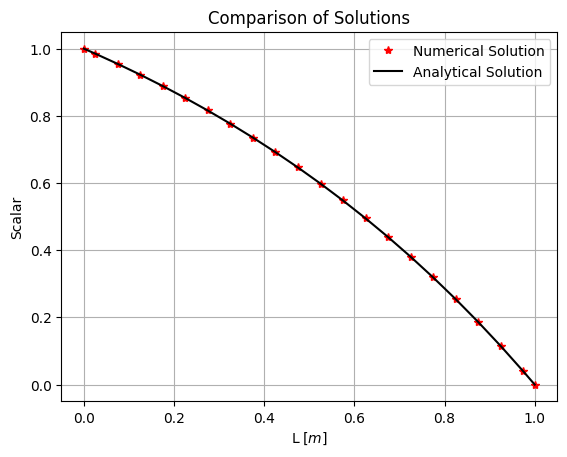

In [577]:
plt.plot(Lx,phi,'r*', label= 'Numerical Solution')
plt.plot(Lx, phi_analytical,'k-', label = 'Analytical Solution')

#Plot axes
plt.xlabel(r'$\text{L}\;[m]$')
plt.ylabel('Scalar')
plt.title('Comparison of Solutions')
plt.grid(True)
plt.legend()

### What about error? ###
As you continue to get exposed to CFD, there are two important aspect that you will need to become familiar with: Validation and Verification

Validation is something you may already be familiar, but it more or less deals with making sure a model or product delivers the expected results. This was done by comparing the results of our numerical model to the analytical solution.

Verification will not be covered here, but it goes more in depth into the actual product or model. For instance, how do we know if the actual equations we are solving are the right choice?

A lot of work is still under way answering the question to those fields! For now, we are going to look at quantifying and comparing the error between our numerical solution to the analytical solution. 

The first error we are going to calculate is the absolute difference error, which is the absolute difference error 
$$ err_{\text{absolute}} = \left|\phi_{\text{numerical}} - \phi_{\text{analytical}}\right| $$

The other error is the relative precentage error

$$ err_{\text{relative}} = \left|\frac{\phi_{\text{numerical}} - \phi_{\text{analytical}}}{{\phi_{\text{analytical}}}}\right| \times 100 $$


In [578]:
def errorAnalysis(phi,phi_analytical):
    absEr = np.abs(phi - phi_analytical)

    # Relative percentage difference
    perRelDiff = ((phi-phi_analytical) / phi_analytical) * 100

    return absEr, perRelDiff

aEr, rEr = errorAnalysis(phi,phi_analytical)

/var/folders/8h/gz5g06vj5cq0rd__xrphnyxw0000gn/T/ipykernel_38830/3565144247.py:5: RuntimeWarning: invalid value encountered in divide
  perRelDiff = ((phi-phi_analytical) / phi_analytical) * 100


### Plot of the Absolute Difference ##

(0.00018788989943718803, 0.0004850906616921252)

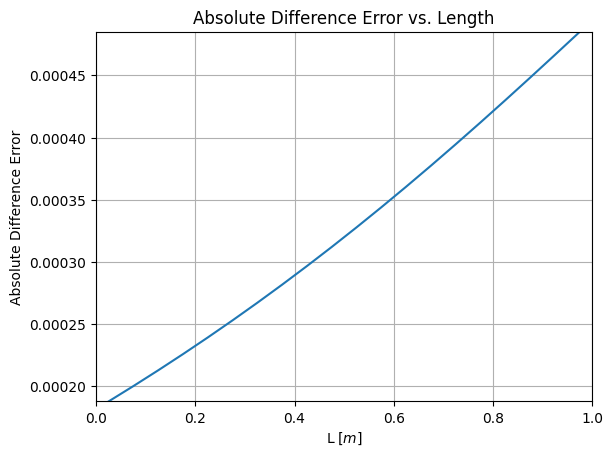

In [579]:
plt.plot(Lx[1:N+1],aEr[1:N+1])
plt.grid(True)
plt.xlabel(r'$\text{L}\;[m]$')
plt.ylabel("Absolute Difference Error")
plt.title("Absolute Difference Error vs. Length")
plt.xlim([0, 1])
plt.ylim([np.min(aEr)+aEr[1], np.max(aEr)])


### Plot of the Relative Error ###

(0.0, 5.0)

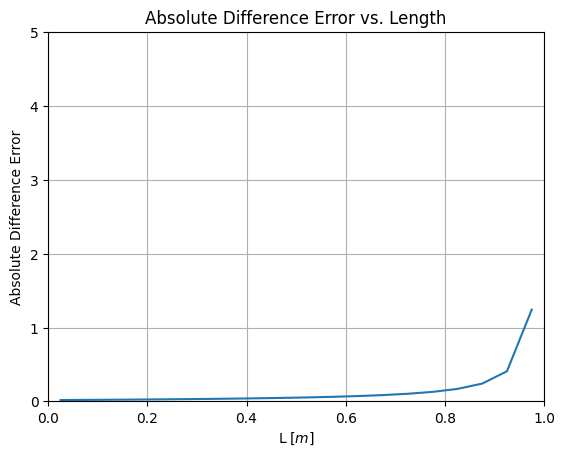

In [580]:
plt.plot(Lx[1:N+1],rEr[1:N+1])
plt.grid(True)
plt.xlabel(r'$\text{L}\;[m]$')
plt.ylabel("Absolute Difference Error")
plt.title("Absolute Difference Error vs. Length")
plt.xlim([0, 1])
plt.ylim([0, 5])
